# Task 6: Per-index EDA — interim data (`data/interim/`)
part 2 of 3 ([raw](eda_raw.ipynb) → interim → [processed](eda_processed.ipynb))

**Goal:** confirm that the Milestone 1 transformations (Task 2 roll-up, Task 3 crosswalk) did what they
were meant to and nothing else, and measure what they introduced: averaged scores, copied scores, and
occupations that fell out.

**Reads:** the five files in `data/interim/`, plus the raw files for reconciliation. **Writes:** nothing.

| Part | Files | Produced by |
|---|---|---|
| 1 | `eloundou_soc6.csv` | Task 2: O\*NET 8-digit codes averaged up to 6-digit SOC |
| 2 | `aioe_soc2018.csv`, `aioe_coverage_log.csv` | Task 3a: AIOE mapped SOC 2010 → 2018 |
| 3 | `frey_osborne_soc2018.csv`, `frey_osborne_coverage_log.csv` | Task 3b: Frey-Osborne mapped SOC 2010 → 2018 |

**Analysis decisions**
- **Reconcile before describing.** Each part first proves every raw row is accounted for (used, or
  logged) and that untouched rows kept their raw value exactly. Only then is the distribution described.
- **Outliers here are created by the pipeline:** codes whose contributing scores disagree, measured as
  the range (max − min) within the code. Thresholds are judgment calls on each index's own scale:
  0.2 for Eloundou (share of tasks), 0.5 sd for AIOE, 0.3 for Frey-Osborne (probability).
- **Coverage is counted on SOC 2018 codes** (867 in total), so the three indices can be compared.

**Carried over from the raw EDA:** Frey-Osborne's 17 unmatchable codes and AIOE's broad Biologists code
(see `eda_raw.ipynb`). Parts 2-3 measure how much coverage they actually cost.

## Setup

Works in **Google Colab** and **locally**:
- **Colab:** mounts Google Drive and reads from the team folder
  `MyDrive/BTT Fall AI Studio (swytch 1b)/data/` (the same folder `Milestone_1.ipynb` uses). If the folder was
  shared with you, add a shortcut to it in *My Drive* first. Any file missing from Drive is downloaded
  from the GitHub repo instead, so the notebook still runs without Drive access.
- **Locally:** reads `data/` from the repo (run from anywhere inside the repo with the project `.venv`).

In [1]:
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)")
else:
    # Repo root = nearest folder (this one or above) that contains data/, so any notebooks/ subfolder works
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir()), Path.cwd())

DATA = ROOT / "data"
# Fallback source for files not found under DATA (switch the branch to main once this is merged)
GITHUB_DATA = "https://raw.githubusercontent.com/Break-Through-Tech/Swytch-1B-do-ai-job-risk-indices-agree/kamsi/data"
print("data folder:", DATA, "(found)" if DATA.exists() else "(not found, using GitHub)")


def data_file(rel):
    """Path to data/<rel>: from Drive / the repo if present, else downloaded once from GitHub."""
    path = DATA / rel
    if path.exists():
        return path
    cached = Path(tempfile.gettempdir()) / "swytch_data" / rel
    if not cached.exists():
        cached.parent.mkdir(parents=True, exist_ok=True)
        print(f"downloading {rel} from GitHub")
        urllib.request.urlretrieve(f"{GITHUB_DATA}/{rel}", cached)
    return cached


OUT = (ROOT if ROOT.exists() else Path.cwd()) / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

MAJOR_GROUPS = {
    "11": "Management", "13": "Business & Financial", "15": "Computer & Mathematical",
    "17": "Architecture & Engineering", "19": "Life, Physical & Social Sci.",
    "21": "Community & Social Service", "23": "Legal", "25": "Education & Library",
    "27": "Arts, Design & Media", "29": "Healthcare Practitioners", "31": "Healthcare Support",
    "33": "Protective Service", "35": "Food Preparation & Serving", "37": "Building & Grounds",
    "39": "Personal Care & Service", "41": "Sales", "43": "Office & Admin Support",
    "45": "Farming, Fishing & Forestry", "47": "Construction & Extraction",
    "49": "Installation & Repair", "51": "Production", "53": "Transportation & Material Moving",
    "55": "Military",
}


def boxplot_by_group(df, code_col, value_col, title):
    """Horizontal boxplot of value_col per SOC major group, sorted by median."""
    groups = df.assign(mg=df[code_col].str[:2]).groupby("mg")[value_col]
    order = groups.median().sort_values().index
    data = [groups.get_group(g) for g in order]
    fig, ax = plt.subplots(figsize=(8, 7))
    try:
        ax.boxplot(data, orientation="horizontal")  # matplotlib >= 3.10
    except TypeError:
        ax.boxplot(data, vert=False)
    ax.set_yticks(range(1, len(order) + 1), [f"{g} {MAJOR_GROUPS[g]}" for g in order])
    ax.set_xlabel(value_col)
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def load_crosswalk():
    """BLS SOC 2010 -> 2018 crosswalk with short column names."""
    cw = pd.read_excel(data_file("raw/soc_2010_to_2018_crosswalk.xlsx"), header=8, dtype=str)
    cw.columns = ["soc10", "title10", "soc18", "title18"]
    return cw.apply(lambda s: s.str.strip())

data folder: C:\Users\Kamsi\Downloads\code\Swytch-1B-do-ai-job-risk-indices-agree\data (found)


In [2]:
cw = load_crosswalk()
soc18 = set(cw.soc18)
print(f"crosswalk: {len(cw)} rows | {cw.soc10.nunique()} SOC 2010 codes | {len(soc18)} SOC 2018 codes")

crosswalk: 900 rows | 840 SOC 2010 codes | 867 SOC 2018 codes


## Part 1 — Eloundou rolled up to 6-digit SOC (`eloundou_soc6.csv`)

Task 2 averages each rating over the O\*NET occupations that share a 6-digit SOC code
(e.g. `11-1011.00` Chief Executives and `11-1011.03` Chief Sustainability Officers → `11-1011`).
No crosswalk is needed: O\*NET-SOC 2019 rolls up directly to SOC 2018.

### 1. Load + integrity checks

In [3]:
elo6 = pd.read_csv(data_file("interim/eloundou_soc6.csv"))
RATINGS = [c for c in elo6.columns if "rating" in c]

print("rows:", len(elo6), "| columns:", list(elo6.columns))
print("nulls:", elo6[["soc6"] + RATINGS].isna().sum().sum(), "| duplicate codes:", elo6.soc6.duplicated().sum())
assert elo6.soc6.str.fullmatch(r"\d{2}-\d{4}").all()
assert elo6[RATINGS].apply(lambda s: s.between(0, 1)).all().all()
# n_children must agree with the listed child codes
assert (elo6.child_codes.str.count(";") + 1 == elo6.n_children).all()
print("O*NET occupations per code:", elo6.n_children.value_counts().sort_index().to_dict())

rows: 798 | columns: ['soc6', 'dv_rating_alpha', 'dv_rating_beta', 'dv_rating_gamma', 'human_rating_alpha', 'human_rating_beta', 'human_rating_gamma', 'n_children', 'child_codes', 'child_titles']
nulls: 0 | duplicate codes: 0
O*NET occupations per code: {1: 731, 2: 42, 3: 11, 4: 7, 5: 1, 6: 3, 7: 1, 8: 1, 9: 1}


### 2. Reconcile with the raw file

In [4]:
elo_raw = pd.read_csv(data_file("raw/occ_level.csv"))
elo_raw["soc6"] = elo_raw["O*NET-SOC Code"].str[:7]

print("raw rows accounted for:", elo6.n_children.sum(), "of", len(elo_raw))
recomputed = elo_raw.groupby("soc6")[RATINGS].mean()
max_diff = (elo6.set_index("soc6")[RATINGS] - recomputed).abs().max().max()
print(f"max |interim - recomputed mean|: {max_diff:.1e}")
print("codes not in SOC 2018:", sorted(set(elo6.soc6) - soc18))

raw rows accounted for: 923 of 923
max |interim - recomputed mean|: 1.1e-16
codes not in SOC 2018: []


### 3. What the averaging hides
For codes with more than one O\*NET occupation, how far apart are the children's scores?
A wide range means the 6-digit average describes none of them well.

In [5]:
spread = elo_raw.groupby("soc6").dv_rating_beta.agg(["count", "min", "max"])
spread = spread[spread["count"] > 1].assign(range=lambda d: d["max"] - d["min"])
wide = spread["range"] > 0.2
print(f"codes averaged from >1 O*NET occupation: {len(spread)} | beta range > 0.2: {wide.sum()}")

(spread.sort_values("range", ascending=False).head(10)
 .join(elo6.set_index("soc6").child_titles).round(2))

codes averaged from >1 O*NET occupation: 67 | beta range > 0.2: 14


,count,min,max,range,child_titles
soc6,,,,,
31-9099,2,0.12,0.61,0.48,Speech-Language Pathology Assistants; Endoscopy Technicians
15-1299,9,0.57,0.97,0.40,Web Administrators; Geographic Information Systems Technologists a...
13-1041,7,0.34,0.68,0.34,Compliance Officers; Environmental Compliance Inspectors; Equal Op...
29-1229,6,0.27,0.57,0.30,Allergists and Immunologists; Hospitalists; Urologists; Physical M...
15-1211,2,0.48,0.75,0.27,Computer Systems Analysts; Health Informatics Specialists
19-1029,4,0.49,0.71,0.23,Bioinformatics Scientists; Molecular and Cellular Biologists; Gene...
11-3051,6,0.29,0.51,0.22,Industrial Production Managers; Quality Control Systems Managers; ...
17-2112,4,0.48,0.70,0.22,Industrial Engineers; Human Factors Engineers and Ergonomists; Val...
33-3021,3,0.32,0.53,0.21,Detectives and Criminal Investigators; Police Identification and R...


### 4. Distribution before vs. after the roll-up

       raw (O*NET)  rolled (SOC 6-digit)
count      923.000               798.000
mean         0.345                 0.326
std          0.221                 0.220
min          0.000                 0.000
25%          0.145                 0.131
50%          0.361                 0.329
75%          0.500                 0.489
max          1.000                 1.000


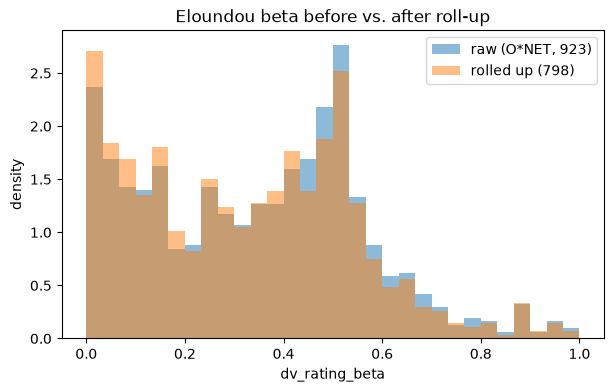

In [6]:
print(pd.DataFrame({"raw (O*NET)": elo_raw.dv_rating_beta.describe(),
                    "rolled (SOC 6-digit)": elo6.dv_rating_beta.describe()}).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(elo_raw.dv_rating_beta, bins=30, alpha=0.5, density=True, label="raw (O*NET, 923)")
ax.hist(elo6.dv_rating_beta, bins=30, alpha=0.5, density=True, label=f"rolled up ({len(elo6)})")
ax.set_xlabel("dv_rating_beta")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Eloundou beta before vs. after roll-up")
plt.show()

### 5. Coverage of SOC 2018

In [7]:
missing = pd.Series(sorted(soc18 - set(elo6.soc6)))
print(f"SOC 2018 codes with no Eloundou rating: {len(missing)} of {len(soc18)}")
print(missing.str[:2].map(lambda g: f"{g} {MAJOR_GROUPS[g]}").value_counts().to_string())

SOC 2018 codes with no Eloundou rating: 69 of 867
55 Military                            19
51 Production                           6
25 Education & Library                  5
27 Arts, Design & Media                 5
53 Transportation & Material Moving     5
21 Community & Social Service           4
43 Office & Admin Support               4
39 Personal Care & Service              3
47 Construction & Extraction            3
29 Healthcare Practitioners             2
35 Food Preparation & Serving           2
37 Building & Grounds                   2
45 Farming, Fishing & Forestry          2
11 Management                           1
17 Architecture & Engineering           1
19 Life, Physical & Social Sci.         1
23 Legal                                1
33 Protective Service                   1
41 Sales                                1
49 Installation & Repair                1


### 6. Summary: key trends, merging, and outliers

**General trends**
- 798 six-digit codes, no nulls or duplicates, all ratings in [0, 1]. 731 codes come from a single
  O\*NET occupation; 67 are averages of 2-9.
- The roll-up is exact: all 923 raw rows are accounted for and every rating equals the recomputed mean
  (difference ~1e-16).
- Beta shifts slightly lower after the roll-up (median 0.36 → 0.33, mean 0.345 → 0.326): each 6-digit
  code now counts once instead of once per O\*NET occupation, so heavily subdivided codes lose weight.

**Merging**
- Every code is a valid SOC 2018 code, so Eloundou joins the other indices directly on `soc`.
- 69 SOC 2018 codes have no Eloundou rating (largest block: 19 military codes); these are the
  `missing_from_eloundou` rows in the coverage report.

**Outliers (created by averaging)**
- 14 of the 67 averaged codes have children more than 0.2 apart on beta. Worst:
  `31-9099` Healthcare Support Workers, All Other (Speech-Language Pathology Assistants 0.61 vs.
  Endoscopy Technicians 0.12), `15-1299` Computer Occupations, All Other (9 children, 0.57-0.97) and
  `13-1041` Compliance Officers (7 children, 0.34-0.68).
- These are mostly "All Other" catch-all codes. Keep them, but consider carrying the within-code range
  as a flag, since their averaged score is the least reliable.

### EDA techniques applied (Eloundou interim)

| Technique | What it was used for | Section |
|---|---|---|
| Null, duplicate, format and range checks | Integrity of the rolled-up table | 1 |
| Internal consistency assert | `n_children` matches the listed child codes | 1 |
| Reconciliation against the raw file | Row totals and recomputed means match exactly | 2 |
| Set comparison against SOC 2018 | Every rolled-up code is a valid 2018 code | 2 |
| Within-group spread (min/max per code) | How much the averaging hides; outliers created by the roll-up | 3 |
| Before/after distribution comparison | Whether the roll-up distorts the score | 4 |
| Coverage analysis by major group | Which 2018 occupations Eloundou does not rate | 5 |

## Part 2 — AIOE mapped to SOC 2018 (`aioe_soc2018.csv`, `aioe_coverage_log.csv`)

Task 3a joins AIOE (SOC 2010) to the crosswalk. A 2010 code that **splits** copies its score to every
2018 child; a 2018 code formed by a **merge** gets the mean of its 2010 parents. 2010 codes with no
crosswalk row go to the coverage log.

### 1. Load + integrity checks

In [8]:
aioe_x = pd.read_csv(data_file("interim/aioe_soc2018.csv"))
aioe_log = pd.read_csv(data_file("interim/aioe_coverage_log.csv"))

print("rows:", len(aioe_x), "| columns:", list(aioe_x.columns))
print("nulls:", aioe_x.isna().sum()[lambda s: s > 0].to_dict(), "| duplicate codes:", aioe_x.soc2018.duplicated().sum())
assert aioe_x.soc2018.str.fullmatch(r"\d{2}-\d{4}").all()
assert (aioe_x.parent_soc2010_codes.str.count(";") + 1 == aioe_x.n_2010_parents).all()
print("2010 parents per 2018 code:", aioe_x.n_2010_parents.value_counts().sort_index().to_dict())
print(f"split children: {aioe_x.is_split.sum()} | merged codes: {aioe_x.is_merge.sum()}")
print("codes not in SOC 2018:", sorted(set(aioe_x.soc2018) - soc18))

rows: 800 | columns: ['soc2018', 'AIOE', 'title_2018', 'n_2010_parents', 'parent_soc2010_codes', 'is_split', 'is_merge']
nulls: {} | duplicate codes: 0
2010 parents per 2018 code: {1: 776, 2: 22, 3: 2}
split children: 76 | merged codes: 24
codes not in SOC 2018: []


### 2. Reconcile with the raw file

In [9]:
aioe_raw = pd.read_excel(data_file("raw/AIOE_DataAppendix.xlsx"), sheet_name="Appendix A").rename(
    columns={"SOC Code": "soc2010", "Occupation Title": "title_2010"})

used = set(aioe_x.parent_soc2010_codes.str.split(";").explode())
logged = set(aioe_log.soc2010)
print(f"raw codes: {len(aioe_raw)} | used as parents: {len(used)} | logged: {len(logged)}"
      f" | unaccounted: {len(set(aioe_raw.soc2010) - used - logged)}")

# Single-parent rows must carry the raw score unchanged
single = aioe_x[aioe_x.n_2010_parents == 1].merge(
    aioe_raw, left_on="parent_soc2010_codes", right_on="soc2010", suffixes=("", "_raw"))
print(f"single-parent rows: {len(single)} | max |interim - raw|: {(single.AIOE - single.AIOE_raw).abs().max():.1e}")

raw codes: 774 | used as parents: 773 | logged: 1 | unaccounted: 0
single-parent rows: 776 | max |interim - raw|: 0.0e+00


### 3. Distribution before vs. after the crosswalk

       raw (SOC 2010)  crosswalked (SOC 2018)
count         774.000                 800.000
mean           -0.000                   0.028
std             1.000                   0.991
min            -2.670                  -2.670
25%            -0.865                  -0.837
50%            -0.051                   0.035
75%             1.014                   1.011
max             1.528                   1.528


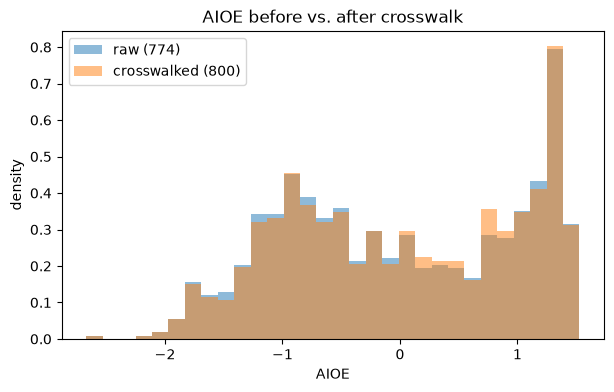

In [10]:
print(pd.DataFrame({"raw (SOC 2010)": aioe_raw.AIOE.describe(),
                    "crosswalked (SOC 2018)": aioe_x.AIOE.describe()}).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aioe_raw.AIOE, bins=30, alpha=0.5, density=True, label=f"raw ({len(aioe_raw)})")
ax.hist(aioe_x.AIOE, bins=30, alpha=0.5, density=True, label=f"crosswalked ({len(aioe_x)})")
ax.set_xlabel("AIOE")
ax.set_ylabel("density")
ax.legend()
ax.set_title("AIOE before vs. after crosswalk")
plt.show()

### 4. Splits and merges
Merge conflicts: 2018 codes whose 2010 parents disagree. The pipeline averages them, so a wide range
means the 2018 score describes neither parent well.

In [11]:
split_parents = cw[cw.soc10.isin(aioe_raw.soc2010)].groupby("soc10").soc18.nunique()
print(f"2010 codes that split: {(split_parents > 1).sum()} -> {aioe_x.is_split.sum()} 2018 codes with a copied score")

pm = cw.merge(aioe_raw[["soc2010", "AIOE"]], left_on="soc10", right_on="soc2010")
aioe_spread = pm.groupby(["soc18", "title18"]).AIOE.agg(["count", "min", "max"])
aioe_spread = aioe_spread[aioe_spread["count"] > 1].assign(range=lambda d: d["max"] - d["min"])
print(f"merged 2018 codes: {len(aioe_spread)} | parents more than 0.5 sd apart: {(aioe_spread['range'] > 0.5).sum()}")
aioe_spread.sort_values("range", ascending=False).head(10).round(2)

2010 codes that split: 35 -> 76 2018 codes with a copied score
merged 2018 codes: 24 | parents more than 0.5 sd apart: 6


,,count,min,max,range
soc18,title18,,,,
51-9162,Computer Numerically Controlled Tool Programmers (##),2,-1.29,-0.02,1.27
39-1013,First-line Supervisors of Gambling Services Workers (##),2,-0.14,1.13,1.27
49-9099,"Installation, Maintenance, and Repair Workers, All Other (##)",2,-1.37,-0.59,0.78
51-9161,Computer Numerically Controlled Tool Operators (##),2,-1.29,-0.67,0.62
25-4022,Librarians and Media Collections Specialists (##),2,0.45,1.04,0.59
15-1299,"Computer Occupations, All Other (##)",2,0.70,1.23,0.53
53-4022,"Railroad Brake, Signal, and Switch Operators and Locomotive Firers (##)",2,-1.22,-0.77,0.45
19-4044,Hydrologic Technicians (##),2,0.08,0.45,0.37
29-9021,Health Information Technologists and Medical Registrars (##),2,0.23,0.57,0.34


### 5. Coverage log and SOC 2018 gaps

In [12]:
print(aioe_log[["soc2010", "title_2010", "AIOE", "reason"]].to_string(index=False))

# Broad codes (ending in 0) stand for several detailed codes; show which
for code_ in aioe_log.soc2010:
    kids = cw[cw.soc10.str.startswith(code_.rstrip("0"))].drop_duplicates("soc10")
    print(f"\n{code_} covers {len(kids)} detailed 2010 codes:")
    print(kids[["soc10", "title10", "soc18"]].to_string(index=False))

soc2010 title_2010     AIOE             reason
19-1020 Biologists 0.752081 no_crosswalk_match

19-1020 covers 4 detailed 2010 codes:
  soc10                            title10   soc18
19-1021      Biochemists and Biophysicists 19-1021
19-1022                    Microbiologists 19-1022
19-1023 Zoologists and Wildlife Biologists 19-1023
19-1029   Biological Scientists, All Other 19-1029


In [13]:
missing = pd.Series(sorted(soc18 - set(aioe_x.soc2018)))
print(f"SOC 2018 codes with no AIOE score: {len(missing)} of {len(soc18)}")
print(missing.str[:2].map(lambda g: f"{g} {MAJOR_GROUPS[g]}").value_counts().to_string())

SOC 2018 codes with no AIOE score: 67 of 867
55 Military                            19
27 Arts, Design & Media                 6
51 Production                           5
21 Community & Social Service           4
39 Personal Care & Service              4
53 Transportation & Material Moving     4
25 Education & Library                  3
43 Office & Admin Support               3
29 Healthcare Practitioners             2
33 Protective Service                   2
35 Food Preparation & Serving           2
37 Building & Grounds                   2
45 Farming, Fishing & Forestry          2
47 Construction & Extraction            2
11 Management                           1
15 Computer & Mathematical              1
17 Architecture & Engineering           1
19 Life, Physical & Social Sci.         1
23 Legal                                1
41 Sales                                1
49 Installation & Repair                1


### 6. Summary: key trends, merging, and outliers

**General trends**
- 800 SOC 2018 codes, no nulls or duplicates, all valid 2018 codes. 776 have one 2010 parent, 22 have
  two and 2 have three.
- The crosswalk is lossless apart from the log: every raw AIOE code is either a parent or logged, and
  single-parent rows carry the raw score unchanged. The distribution is essentially unchanged
  (mean 0.03 vs. 0, sd 0.99 vs. 1).

**Merging**
- 76 2018 codes inherit a copied score through a split; these are duplicates of their parent's score,
  not independent measurements, which matters for any correlation or ranking.
- The coverage log has one row, `19-1020` Biologists, a broad code covering four detailed codes. It can
  be recovered by giving its score to those children (not done yet; kept in the log per the team's
  don't-delete note).
- 67 SOC 2018 codes have no AIOE score (largest block: military).

**Outliers (created by merging)**
- 6 of the 24 merges have parents more than 0.5 sd apart; `51-9162` CNC Tool Programmers and `39-1013`
  Gambling Supervisors average parents ~1.27 sd apart. The `is_merge` flag marks these; keep and flag
  them rather than drop them.

### EDA techniques applied (AIOE interim)

| Technique | What it was used for | Section |
|---|---|---|
| Null, duplicate and format checks | Integrity of the crosswalked table | 1 |
| Internal consistency assert | `n_2010_parents` matches the listed parent codes | 1 |
| Set reconciliation (parents + log = raw) | Confirm no AIOE code was silently lost | 2 |
| Value reconciliation | Single-parent rows keep the raw score | 2 |
| Before/after distribution comparison | Whether the crosswalk distorts scores | 3 |
| Split counting | How many scores are copies rather than measurements | 4 |
| Within-group spread (min/max per merged code) | Merge conflicts: value outliers created by averaging | 4 |
| Broad-code expansion | What the logged code stands for and how to recover it | 5 |
| Coverage analysis by major group | Which 2018 occupations AIOE does not score | 5 |

## Part 3 — Frey-Osborne mapped to SOC 2018 (`frey_osborne_soc2018.csv`, `frey_osborne_coverage_log.csv`)

Task 3b parses the paper's appendix (702 occupations, SOC 2010) and maps it to SOC 2018 the same way
as AIOE: splits copy, merges average, unmatched codes are logged.

### 1. Load + integrity checks

In [14]:
fo_x = pd.read_csv(data_file("interim/frey_osborne_soc2018.csv"))
fo_log = pd.read_csv(data_file("interim/frey_osborne_coverage_log.csv"), dtype={"soc2010": str})

print("rows:", len(fo_x), "| columns:", list(fo_x.columns))
print("nulls:", fo_x.isna().sum()[lambda s: s > 0].to_dict(), "| duplicate codes:", fo_x.soc2018.duplicated().sum())
assert fo_x.soc2018.str.fullmatch(r"\d{2}-\d{4}").all()
assert fo_x.probability.between(0, 1).all()
assert (fo_x.parent_soc2010_codes.str.count(";") + 1 == fo_x.n_2010_parents).all()
print("2010 parents per 2018 code:", fo_x.n_2010_parents.value_counts().sort_index().to_dict())
print(f"split children: {fo_x.is_split.sum()} | merged codes: {fo_x.is_merge.sum()}")
print("codes not in SOC 2018:", sorted(set(fo_x.soc2018) - soc18))

rows: 699 | columns: ['soc2018', 'probability', 'title_2018', 'n_2010_parents', 'parent_soc2010_codes', 'is_split', 'is_merge']
nulls: {} | duplicate codes: 0
2010 parents per 2018 code: {1: 683, 2: 16}
split children: 48 | merged codes: 16
codes not in SOC 2018: []


### 2. Reconcile with the raw PDF

In [15]:
import re

try:
    import pdfplumber
except ImportError:  # not preinstalled on Colab
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pdfplumber"])
    import pdfplumber

FO_ROW = re.compile(r"^(\d+)\.\s+([\d.]+)\s+(?:(\d)\s+)?(\d{2}-\d{4})\s+(.+)$")
rows = []
with pdfplumber.open(data_file("raw/The_Future_of_Employment.pdf")) as pdf:
    for page in pdf.pages[56:]:
        for line in (page.extract_text() or "").split("\n"):
            m = FO_ROW.match(line.strip())
            if m:
                rows.append({"soc2010": m.group(4), "probability": float(m.group(2))})
fo_raw = pd.DataFrame(rows)

used = set(fo_x.parent_soc2010_codes.str.split(";").explode())
logged = set(fo_log.soc2010)
print(f"raw codes: {len(fo_raw)} | used as parents: {len(used)} | logged: {len(logged)}"
      f" | unaccounted: {len(set(fo_raw.soc2010) - used - logged)}")

single = fo_x[fo_x.n_2010_parents == 1].merge(
    fo_raw, left_on="parent_soc2010_codes", right_on="soc2010", suffixes=("", "_raw"))
print(f"single-parent rows: {len(single)} | max |interim - raw|: {(single.probability - single.probability_raw).abs().max():.1e}")

raw codes: 702 | used as parents: 685 | logged: 17 | unaccounted: 0
single-parent rows: 683 | max |interim - raw|: 0.0e+00


### 3. Distribution before vs. after the crosswalk

                  raw (SOC 2010)  crosswalked (SOC 2018)
probability                                             
low (<0.3)                   241                     243
medium (0.3-0.7)             145                     139
high (>0.7)                  316                     317


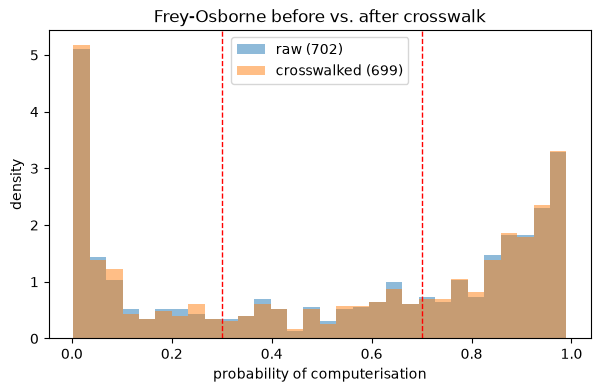

In [16]:
BANDS = dict(bins=[0, 0.3, 0.7, 1], include_lowest=True, labels=["low (<0.3)", "medium (0.3-0.7)", "high (>0.7)"])
print(pd.DataFrame({"raw (SOC 2010)": pd.cut(fo_raw.probability, **BANDS).value_counts(),
                    "crosswalked (SOC 2018)": pd.cut(fo_x.probability, **BANDS).value_counts()}).sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fo_raw.probability, bins=30, alpha=0.5, density=True, label=f"raw ({len(fo_raw)})")
ax.hist(fo_x.probability, bins=30, alpha=0.5, density=True, label=f"crosswalked ({len(fo_x)})")
for x in (0.3, 0.7):
    ax.axvline(x, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("probability of computerisation")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Frey-Osborne before vs. after crosswalk")
plt.show()

### 4. Splits and merges

In [17]:
pm = cw.merge(fo_raw, left_on="soc10", right_on="soc2010")
fo_spread = pm.groupby(["soc18", "title18"]).probability.agg(["count", "min", "max"])
fo_spread = fo_spread[fo_spread["count"] > 1].assign(range=lambda d: d["max"] - d["min"])
print(f"merged 2018 codes: {len(fo_spread)} | parents more than 0.3 apart: {(fo_spread['range'] > 0.3).sum()}")
fo_spread.sort_values("range", ascending=False).head(10).round(2)

merged 2018 codes: 16 | parents more than 0.3 apart: 2


,,count,min,max,range
soc18,title18,,,,
47-5032,"Explosives Workers, Ordnance Handling Experts, and Blasters (##)",2,0.48,0.85,0.37
19-4044,Hydrologic Technicians (##),2,0.61,0.91,0.30
39-1013,First-line Supervisors of Gambling Services Workers (##),2,0.28,0.54,0.26
25-4022,Librarians and Media Collections Specialists (##),2,0.39,0.65,0.26
51-9124,"Coating, Painting, and Spraying Machine Setters, Operators, and Tenders (##)",2,0.69,0.91,0.22
47-5044,"Loading and Moving Machine Operators, Underground Mining (##)",2,0.37,0.50,0.13
53-4022,"Railroad Brake, Signal, and Switch Operators and Locomotive Firers (##)",2,0.83,0.93,0.10
13-2054,Financial Risk Specialists (##),2,0.23,0.33,0.10
15-1252,Software Developers (##),2,0.04,0.13,0.09


### 5. Coverage log: what was dropped and why

In [18]:
titles10 = cw.drop_duplicates("soc10").set_index("soc10").title10
fo_log["kind"] = "not a SOC 2010 detailed code"
fo_log.loc[fo_log.soc2010.str.endswith("0"), "kind"] = "broad code (ends in 0)"
fo_log["major_group"] = fo_log.soc2010.str[:2].map(lambda g: f"{g} {MAJOR_GROUPS[g]}")
print(fo_log.kind.value_counts().to_string())
print()
print(fo_log.major_group.value_counts().to_string())
fo_log[["rank", "probability", "soc2010", "title_2010", "kind"]]

kind
not a SOC 2010 detailed code    13
broad code (ends in 0)           4

major_group
29 Healthcare Practitioners       5
15 Computer & Mathematical        3
25 Education & Library            2
39 Personal Care & Service        1
13 Business & Financial           1
49 Installation & Repair          1
31 Healthcare Support             1
47 Construction & Extraction      1
45 Farming, Fishing & Forestry    1
51 Production                     1


,rank,probability,soc2010,title_2010,kind
0,15,0.0042,29-1060,PhysiciansandSurgeons,broad code (ends in 0)
1,46,0.0090,29-1111,RegisteredNurses,not a SOC 2010 detailed code
2,48,0.0095,25-3999,"TeachersandInstructors,AllOther",not a SOC 2010 detailed code
3,112,0.0320,25-1000,PostsecondaryTeachers,broad code (ends in 0)
4,142,0.0550,29-9799,"HealthcarePractitionersandTechnicalWorkers,AllOther",not a SOC 2010 detailed code
5,207,0.2000,39-4831,"FuneralServiceManagers,Directors,Morticians,andUndertakers",not a SOC 2010 detailed code
6,208,0.2100,15-1179,"Information Security Analysts, Web Developers, and Computer Net-",not a SOC 2010 detailed code
7,212,0.2200,15-1799,"ComputerOccupations,AllOther",not a SOC 2010 detailed code
8,218,0.2300,29-2037,RadiologicTechnologistsandTechnicians,not a SOC 2010 detailed code
9,242,0.3100,13-1078,"HumanResources,Training,andLaborRelationsSpecialists,AllOther",not a SOC 2010 detailed code


In [19]:
missing18 = soc18 - set(fo_x.soc2018)
print(f"SOC 2018 codes with no Frey-Osborne score: {len(missing18)} of {len(soc18)}")
print(pd.Series(sorted(missing18)).str[:2].map(lambda g: f"{g} {MAJOR_GROUPS[g]}").value_counts().head(8).to_string())

# How many of those would come back if each broad code's score were given to its detailed children
recovery = []
for _, r in fo_log[fo_log.kind.str.startswith("broad")].iterrows():
    kids = cw[cw.soc10.str.startswith(r.soc2010.rstrip("0"))]
    recovery.append({"broad code": r.soc2010, "title (as parsed)": r.title_2010,
                     "2010 children": kids.soc10.nunique(),
                     "2018 codes recovered": len(set(kids.soc18) & missing18)})
recovery = pd.DataFrame(recovery)
print(f"\n2018 codes recoverable from broad codes: {recovery['2018 codes recovered'].sum()} of {len(missing18)}")
recovery

SOC 2018 codes with no Frey-Osborne score: 168 of 867
25 Education & Library           46
29 Healthcare Practitioners      32
55 Military                      19
15 Computer & Mathematical        7
27 Arts, Design & Media           6
51 Production                     6
21 Community & Social Service     5
33 Protective Service             5

2018 codes recoverable from broad codes: 61 of 168


,broad code,title (as parsed),2010 children,2018 codes recovered
0,29-1060,PhysiciansandSurgeons,8,17
1,25-1000,PostsecondaryTeachers,38,38
2,15-1150,ComputerSupportSpecialists,2,2
3,45-2090,MiscellaneousAgriculturalWorkers,4,4


### 6. Summary: key trends, merging, and outliers

**General trends**
- 699 SOC 2018 codes, no nulls or duplicates, all probabilities in [0, 1]. 683 have one 2010 parent,
  16 have two.
- The crosswalk is lossless apart from the log: all 702 raw codes are parents (685) or logged (17), and
  single-parent rows keep the raw probability. The bimodal shape and risk-band mix survive the crosswalk.

**Merging**
- **Frey-Osborne is the weakest link in the join.** 168 SOC 2018 codes have no FO score, far more than
  AIOE (67) or Eloundou (69), and they are concentrated in education (46) and healthcare practitioners
  (32). That is why `missing_from_frey_osborne` dominates the coverage report (97 of 115 drops) and why
  the merged table under-represents high-AI-exposure professional jobs.
- The cause is the 17 logged codes, which are low-risk healthcare and education occupations the paper
  lists under non-SOC-2010 codes:
  - **4 broad codes** (`29-1060` Physicians and Surgeons, `25-1000` Postsecondary Teachers, `15-1150`,
    `45-2090`): giving each broad score to its detailed children would recover **61** of the 168 missing
    2018 codes (38 postsecondary teacher codes, 17 physician codes).
  - **13 SOC 2000 / aggregate codes** (e.g. `29-1111` Registered Nurses, which is `29-1141` in SOC 2010;
    `x-x799` "All Other" groups): need a hand mapping checked against the BLS SOC 2000 → 2010 crosswalk.
- Recommendation for the meeting: add these mappings to Task 3b, flag recovered rows with a provenance
  column, and keep the log (don't delete data).

**Outliers (created by merging)**
- Only 16 merges, and 2 have parents more than 0.3 apart: `47-5032` Explosives Workers (0.48-0.85) and
  `19-4044` Hydrologic Technicians (0.61-0.91). Keep and flag via `is_merge`.

### EDA techniques applied (Frey-Osborne interim)

| Technique | What it was used for | Section |
|---|---|---|
| Null, duplicate, format and range checks | Integrity of the crosswalked table | 1 |
| Internal consistency assert | `n_2010_parents` matches the listed parent codes | 1 |
| PDF re-extraction + set reconciliation | All 702 raw codes are parents or logged | 2 |
| Value reconciliation | Single-parent rows keep the raw probability | 2 |
| Binning + before/after comparison | Risk bands and bimodality survive the crosswalk | 3 |
| Within-group spread (min/max per merged code) | Merge conflicts | 4 |
| Code classification (broad vs. non-SOC-2010) | Why logged codes failed to match | 5 |
| Coverage analysis by major group | Which 2018 occupations lack a score, and the resulting bias | 5 |
| What-if recovery count | How much coverage mapping the broad codes would restore | 5 |

## Result and retained limitations

- **All three transformations are lossless apart from their logs.** Every raw Eloundou row is in a
  six-digit average; every raw AIOE and Frey-Osborne code is either a parent of a 2018 code or in the
  coverage log. Untouched rows carry their raw values exactly.
- **What the transformations introduced:**
  - *Averaged scores:* 67 Eloundou codes (14 with children more than 0.2 apart), 24 AIOE merges, and 16 Frey-Osborne merges.
  - *Copied scores:* splits give several 2018 codes an identical score (76 for AIOE, 48 for Frey-Osborne).
    These are copies, not independent measurements.
- **Coverage is uneven.** Frey-Osborne misses 168 SOC 2018 codes, against 67 for AIOE and 69 for Eloundou,
  concentrated in education and healthcare. Expanding its four broad codes would recover 61 of them.
- The logged codes are kept, not deleted, in line with the team's don't-delete-data note.

This notebook does not change any file; recovering the Frey-Osborne and AIOE broad codes is a Task 3
change for the team to decide. **Next:** [`eda_processed.ipynb`](eda_processed.ipynb) looks at what
survives the three-way join.